In [ ]:
# 3B.1 Build the Transformer
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

# Hyperparameters
D_MODEL=64
N_HEADS=4
N_LAYERS=3
BLOCK_SIZE=128
FF_DIM=256
DROPOUT=0.1
D_HEAD=D_MODEL//N_HEADS  # 16
MAX_ITERS=3000
BATCH_SIZE=32
EVAL_EVERY=100
EVAL_ITERS=100
LR=3e-4

# Data
with open("Q3_inputtext.txt", "r", encoding="utf-8") as f:
  text=f.read()

chars=sorted(set(text))
VOCAB_SIZE=len(chars)
stoi={ch:i for i, ch in enumerate(chars)}
itos={i:ch for i, ch in enumerate(chars)}
encode=lambda s: [stoi[c] for c in s]
decode=lambda l: "".join(itos[i] for i in l)

data=torch.tensor(encode(text), dtype=torch.long)
n=int(0.9*len(data))
train_data=data[:n]
val_data=data[n:]
device="cuda" if torch.cuda.is_available() else "cpu"

def get_batch(split):
  d=train_data if split=="train" else val_data
  ix=torch.randint(len(d)-BLOCK_SIZE, (BATCH_SIZE,))
  x=torch.stack([d[i: i+BLOCK_SIZE] for i in ix])
  y=torch.stack([d[i+1: i+1+BLOCK_SIZE] for i in ix])
  return x.to(device), y.to(device)

@torch.no_grad()
def estimate_loss(model):
  model.eval()
  out={}
  for split in ("train", "val"):
    losses=torch.zeros(EVAL_ITERS)
    for k in range(EVAL_ITERS):
      xb, yb=get_batch(split)
      _, loss=model(xb, yb)
      losses[k]=loss.item()
    out[split]=losses.mean().item()
  model.train()
  return out

# Model components

class MultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.W_q=nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.W_k=nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.W_v=nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.W_o=nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.drop=nn.Dropout(DROPOUT)
        self.register_buffer("mask", torch.tril(torch.ones(BLOCK_SIZE, BLOCK_SIZE)))
        # will store last attention weights for visualisation
        self.last_attn_weights=None

    def forward(self, x):
        B, T, C=x.shape
        Q=self.W_q(x).view(B, T, N_HEADS, D_HEAD).transpose(1, 2)
        K=self.W_k(x).view(B, T, N_HEADS, D_HEAD).transpose(1, 2)
        V=self.W_v(x).view(B, T, N_HEADS, D_HEAD).transpose(1, 2)

        attn=Q@K.transpose(-2, -1)/math.sqrt(D_HEAD)
        attn=attn.masked_fill(self.mask[:T, :T]==0, float("-inf"))
        attn=F.softmax(attn, dim=-1)
        self.last_attn_weights=attn.detach()   # (B, H, T, T)
        attn=self.drop(attn)

        out=attn@V
        out=out.transpose(1, 2).contiguous().view(B, T, C)
        return self.W_o(out)


class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 =nn.Linear(D_MODEL, FF_DIM)
        self.fc2 =nn.Linear(FF_DIM, D_MODEL)
        self.drop=nn.Dropout(DROPOUT)

    def forward(self, x):
        return self.drop(self.fc2(F.gelu(self.fc1(x))))


class TransformerBlock(nn.Module):
    def __init__(self, pre_norm=True):
        super().__init__()
        self.pre_norm=pre_norm
        self.ln1 =nn.LayerNorm(D_MODEL)
        self.ln2=nn.LayerNorm(D_MODEL)
        self.attn=MultiHeadAttention()
        self.ff=FeedForward()
        self.drop=nn.Dropout(DROPOUT)

    def forward(self, x):
        if self.pre_norm:
            x=x+self.drop(self.attn(self.ln1(x)))
            x=x+self.drop(self.ff(self.ln2(x)))
        else:
            x=self.ln1(x+self.drop(self.attn(x)))
            x=self.ln2(x+self.drop(self.ff(x)))
        return x


class TinyTransformer(nn.Module):
    def __init__(self, pre_norm=True):
        super().__init__()
        self.tok_emb=nn.Embedding(VOCAB_SIZE, D_MODEL)
        self.pos_emb=nn.Embedding(BLOCK_SIZE, D_MODEL)
        self.drop=nn.Dropout(DROPOUT)
        self.blocks=nn.ModuleList([TransformerBlock(pre_norm) for _ in range(N_LAYERS)])
        self.ln_f=nn.LayerNorm(D_MODEL)
        self.head=nn.Linear(D_MODEL, VOCAB_SIZE, bias=False)

    def forward(self, idx, targets=None):
        B, T=idx.shape
        pos=torch.arange(T, device=idx.device)
        x=self.drop(self.tok_emb(idx)+self.pos_emb(pos))
        for block in self.blocks:
            x=block(x)
        x=self.ln_f(x)
        logits=self.head(x)
        loss=None
        if targets is not None:
            loss=F.cross_entropy(logits.view(-1, VOCAB_SIZE), targets.view(-1))
        return logits, loss

In [9]:
# 3B.1 Build the Transformer
model_pre=TinyTransformer(pre_norm=True).to(device)
total_params=sum(p.numel() for p in model_pre.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 167,232



── Training Pre-Norm ───────────────────────────────────
[Pre-Norm] step    0 | train 4.4819 | val 4.4898
[Pre-Norm] step  100 | train 2.9236 | val 2.9244
[Pre-Norm] step  200 | train 2.6876 | val 2.6896
[Pre-Norm] step  300 | train 2.5942 | val 2.5929
[Pre-Norm] step  400 | train 2.5469 | val 2.5454
[Pre-Norm] step  500 | train 2.5092 | val 2.5097
[Pre-Norm] step  600 | train 2.4932 | val 2.4848
[Pre-Norm] step  700 | train 2.4586 | val 2.4696
[Pre-Norm] step  800 | train 2.4476 | val 2.4496
[Pre-Norm] step  900 | train 2.4314 | val 2.4362
[Pre-Norm] step 1000 | train 2.4206 | val 2.4215
[Pre-Norm] step 1100 | train 2.4103 | val 2.4178
[Pre-Norm] step 1200 | train 2.4001 | val 2.4011
[Pre-Norm] step 1300 | train 2.3922 | val 2.3976
[Pre-Norm] step 1400 | train 2.3721 | val 2.3808
[Pre-Norm] step 1500 | train 2.3601 | val 2.3640
[Pre-Norm] step 1600 | train 2.3489 | val 2.3541
[Pre-Norm] step 1700 | train 2.3277 | val 2.3377
[Pre-Norm] step 1800 | train 2.3083 | val 2.3162
[Pre-Norm] 

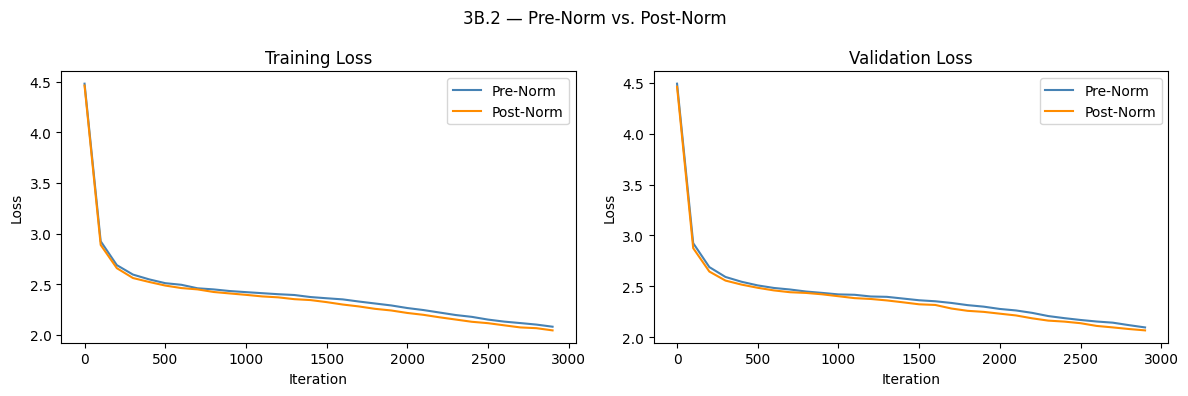

In [10]:
# 3B.2 Pre-Norm vs. Post-Norm Training Comparison
def train(model, label):
  opt=torch.optim.Adam(model.parameters(), lr=LR)
  history={"step": [], "train": [], "val": []}
  for step in range(MAX_ITERS):
    if step%EVAL_EVERY==0:
      losses=estimate_loss(model)
      history["step"].append(step)
      history["train"].append(losses["train"])
      history["val"].append(losses["val"])
      print(f"[{label}] step {step:4d} | train {losses['train']:.4f} | val {losses['val']:.4f}")
    xb, yb=get_batch("train")
    _, loss=model(xb, yb)
    opt.zero_grad()
    loss.backward()
    opt.step()
  return history

print("\n── Training Pre-Norm ───────────────────────────────────")
model_pre=TinyTransformer(pre_norm=True).to(device)
hist_pre=train(model_pre, "Pre-Norm")

print("\n── Training Post-Norm ──────────────────────────────────")
model_post=TinyTransformer(pre_norm=False).to(device)
hist_post=train(model_post, "Post-Norm")

# Plot
fig, (ax1, ax2)=plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist_pre["step"], hist_pre["train"], label="Pre-Norm", color="steelblue")
ax1.plot(hist_post["step"], hist_post["train"], label="Post-Norm", color="darkorange")
ax1.set_xlabel("Iteration"); ax1.set_ylabel("Loss")
ax1.set_title("Training Loss"); ax1.legend()

ax2.plot(hist_pre["step"], hist_pre["val"], label="Pre-Norm", color="steelblue")
ax2.plot(hist_post["step"], hist_post["val"], label="Post-Norm", color="darkorange")
ax2.set_xlabel("Iteration"); ax2.set_ylabel("Loss")
ax2.set_title("Validation Loss"); ax2.legend()

plt.suptitle("3B.2 — Pre-Norm vs. Post-Norm"); plt.tight_layout()
plt.show()

Post-Norm converges slightly faster. Its loss drops more quickly in the early iterations (at 0-500 steps it is consistently lower than Pre-Norm).

Post-Norm achieves a lower final loss. By ~2900 steps, Post-Norm reaches 2.04(train)/2.07(val), whereas Pre-Norm is higher at 2.08/2.10.

Neither version shows noticeable instability. Both curves are smooth and monotonic with no significant spikes. However, Post-Norm appears slightly more consistently decreasing, while Pre-Norm has marginally flatter regions.

In [11]:
# 3B.3 Text Generation
def generate(model, prompt, max_len=200, temperature=1.0):
  model.eval()
  idx=torch.tensor([encode(prompt)], dtype=torch.long, device=device)
  with torch.no_grad():
    for _ in range(max_len):
      idx_cond=idx[:, -BLOCK_SIZE:]
      logits, _=model(idx_cond)
      logits=logits[:, -1, :]/temperature
      probs=F.softmax(logits, dim=-1)
      next_tok=torch.multinomial(probs, num_samples=1)
      idx=torch.cat([idx, next_tok], dim=1)
  return decode(idx[0].tolist())

prompt="The hero "
print("\n── 3B.3 Text Generation ────────────────────────────────")
for T in [0.2, 1.0, 1.5]:
  out=generate(model_pre, prompt, max_len=200, temperature=T)
  print(f"\nTemperature={T}:\n{out}")


── 3B.3 Text Generation ────────────────────────────────

Temperature=0.2:
The hero the the the was the and the the ard the she she was the she she was s the she was the o to at
an the the the the the wat as and the the the he was the the the as she the the she was she the she she
ch

Temperature=1.0:
The hero he se inor ish, amikef as gat
ititing ing cas along, thily arponeace s fiethe and lving ito alolursle,
“I toun’l Mous,”
aid A,” the tbere saile quind tte lasl

gech.” the Greer, Alice s andownd shade 

Temperature=1.5:
The hero cly’then. rke “What,” he; ind rithid the Fats;” she tar” moaie figmep pains;”
hofe, A “Frtlejhe!”

Aled Flly Kldshel’d me an pe’s he  oqtarre pus?”,

“R!” tank_sop hery hou: andg,” she thetlerpacem* S


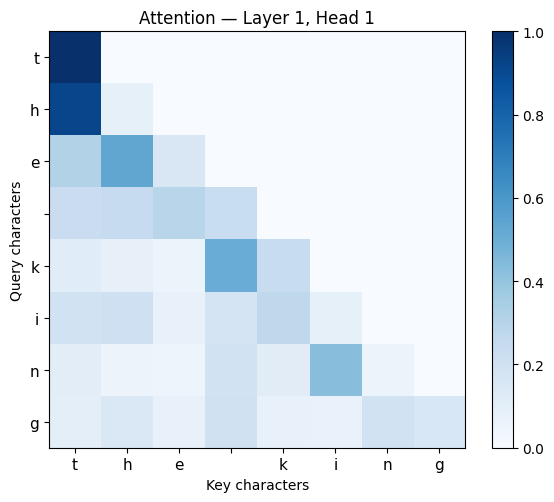

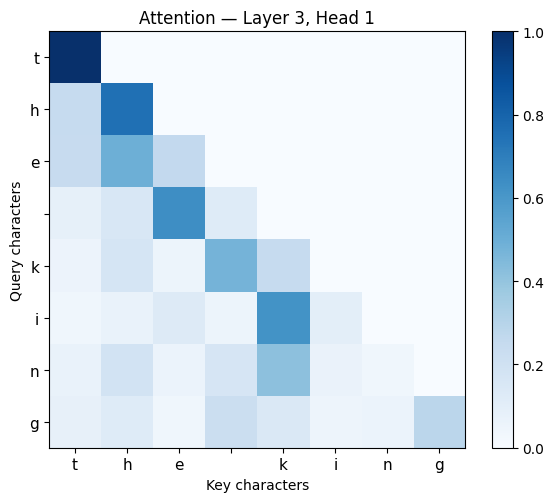

In [12]:
# 3B.4 Attention Visualization
def get_attention_weights(model, text_input):
  # Returns list of attention weight tensors, one per layer: (H, T, T)
  model.eval()
  idx=torch.tensor([encode(text_input)], dtype=torch.long, device=device)
  with torch.no_grad():
    model(idx)
  return [block.attn.last_attn_weights[0].cpu() for block in model.blocks]

def plot_attn_heatmap(weights, chars_list, layer_idx, head_idx, filename):
    T=len(chars_list)
    mat=weights[layer_idx][head_idx, :T, :T].numpy()
    fig, ax=plt.subplots(figsize=(6, 5))
    im=ax.imshow(mat, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(T)); ax.set_xticklabels(chars_list, fontsize=11)
    ax.set_yticks(range(T)); ax.set_yticklabels(chars_list, fontsize=11)
    ax.set_xlabel("Key characters"); ax.set_ylabel("Query characters")
    ax.set_title(f"Attention — Layer {layer_idx+1}, Head {head_idx+1}")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

text_input="the king"
chars_list=list(text_input)
attn_all=get_attention_weights(model_pre, text_input)

# First layer, head 0
plot_attn_heatmap(attn_all, chars_list, layer_idx=0, head_idx=0, filename="3b4_attn_layer1_head1.png")

# Last layer, head 0
plot_attn_heatmap(attn_all, chars_list, layer_idx=N_LAYERS-1, head_idx=0, filename="3b4_attn_layer3_head1.png")